# EDA on a messy employee dataset
### The general cleaning, analyzing and visualizing of an employee dataset and generating insight from a messy employee dataset

# Part 1
## Data Cleaning

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Loading the data and making a copy of it to clean

In [4]:
data = pd.read_csv('Messy_Employee_dataset.csv')
df = data.copy()

In [5]:
df.head()

,Employee_ID,First_Name,Last_Name,Age,Department_Region,Status,Join_Date,Salary,Email,Phone,Performance_Score,Remote_Work
0,EMP1000,Bob,Davis,25.0,DevOps-California,Active,4/2/2021,59767.65,bob.davis@example.com,-1651623197,Average,True
1,EMP1001,Bob,Brown,NaN,Finance-Texas,Active,7/10/2020,65304.66,bob.brown@example.com,-1898471390,Excellent,True
2,EMP1002,Alice,Jones,NaN,Admin-Nevada,Pending,12/7/2023,88145.90,alice.jones@example.com,-5596363211,Good,True
3,EMP1003,Eva,Davis,25.0,Admin-Nevada,Inactive,11/27/2021,69450.99,eva.davis@example.com,-3476490784,Good,True
4,EMP1004,Frank,Williams,25.0,Cloud Tech-Florida,Active,1/5/2022,109324.61,frank.williams@example.com,-1586734256,Poor,False


### Inspecting the dataset

In [6]:
df.shape

(1020, 12)

In [7]:
df.isnull().sum()

Employee_ID            0
First_Name             0
Last_Name              0
Age                  211
Department_Region      0
Status                 0
Join_Date              0
Salary                24
Email                  0
Phone                  0
Performance_Score      0
Remote_Work            0
dtype: int64

In [8]:
#### Two columns that have missing values
df.isnull().sum().sum()
### General namount of missing values

np.int64(235)

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.dtypes

Employee_ID              str
First_Name               str
Last_Name                str
Age                  float64
Department_Region        str
Status                   str
Join_Date                str
Salary               float64
Email                    str
Phone                  int64
Performance_Score        str
Remote_Work             bool
dtype: object

### After inspection of the data i found out that there are:
- No duplicates
- Missing Values in the Age and Salary column
- A splitable column
- Inconsistent Date formats

### Cleaning the dataset

In [11]:
df.head()

,Employee_ID,First_Name,Last_Name,Age,Department_Region,Status,Join_Date,Salary,Email,Phone,Performance_Score,Remote_Work
0,EMP1000,Bob,Davis,25.0,DevOps-California,Active,4/2/2021,59767.65,bob.davis@example.com,-1651623197,Average,True
1,EMP1001,Bob,Brown,NaN,Finance-Texas,Active,7/10/2020,65304.66,bob.brown@example.com,-1898471390,Excellent,True
2,EMP1002,Alice,Jones,NaN,Admin-Nevada,Pending,12/7/2023,88145.90,alice.jones@example.com,-5596363211,Good,True
3,EMP1003,Eva,Davis,25.0,Admin-Nevada,Inactive,11/27/2021,69450.99,eva.davis@example.com,-3476490784,Good,True
4,EMP1004,Frank,Williams,25.0,Cloud Tech-Florida,Active,1/5/2022,109324.61,frank.williams@example.com,-1586734256,Poor,False


In [12]:
df['First_Name'].unique()

<ArrowStringArray>
['Bob', 'Alice', 'Eva', 'Frank', 'Charlie', 'David', 'Heidi', 'Grace']
Length: 8, dtype: str

In [13]:
### Checking for empty cells in the column
df[df['First_Name'] == '']

,Employee_ID,First_Name,Last_Name,Age,Department_Region,Status,Join_Date,Salary,Email,Phone,Performance_Score,Remote_Work


In [14]:
### Checking for name that contain white spaces 
### This also removes whithe spaces at the beginning and at the end
df[df['First_Name'].str.strip() == '']

,Employee_ID,First_Name,Last_Name,Age,Department_Region,Status,Join_Date,Salary,Email,Phone,Performance_Score,Remote_Work


In [15]:
df['Last_Name'].unique()

<ArrowStringArray>
['Davis', 'Brown', 'Jones', 'Williams', 'Garcia', 'Johnson', 'Miller',
 'Smith']
Length: 8, dtype: str

In [16]:
df[df['Last_Name'] == '']

,Employee_ID,First_Name,Last_Name,Age,Department_Region,Status,Join_Date,Salary,Email,Phone,Performance_Score,Remote_Work


In [17]:
df[df['Last_Name'].str.strip() == '']

,Employee_ID,First_Name,Last_Name,Age,Department_Region,Status,Join_Date,Salary,Email,Phone,Performance_Score,Remote_Work


In [18]:
df.head()

,Employee_ID,First_Name,Last_Name,Age,Department_Region,Status,Join_Date,Salary,Email,Phone,Performance_Score,Remote_Work
0,EMP1000,Bob,Davis,25.0,DevOps-California,Active,4/2/2021,59767.65,bob.davis@example.com,-1651623197,Average,True
1,EMP1001,Bob,Brown,NaN,Finance-Texas,Active,7/10/2020,65304.66,bob.brown@example.com,-1898471390,Excellent,True
2,EMP1002,Alice,Jones,NaN,Admin-Nevada,Pending,12/7/2023,88145.90,alice.jones@example.com,-5596363211,Good,True
3,EMP1003,Eva,Davis,25.0,Admin-Nevada,Inactive,11/27/2021,69450.99,eva.davis@example.com,-3476490784,Good,True
4,EMP1004,Frank,Williams,25.0,Cloud Tech-Florida,Active,1/5/2022,109324.61,frank.williams@example.com,-1586734256,Poor,False


### Function for finding outliers

In [19]:
def find_outlier(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    higher_limit = Q3 + 1.5 * IQR


    return lower_limit, higher_limit

In [20]:
## Age Outlier
ageoutlier = find_outlier(df, 'Age')
print(ageoutlier)

(np.float64(2.5), np.float64(62.5))


In [21]:
agelower_limit = 2.5
agehigher_limit = 62.5

for index, row in df.iterrows():
    if (row['Age'] < agelower_limit) or (row['Age'] > agehigher_limit):
        print(row)

In [22]:
agemean = df['Age'].mean()
agemedian = df['Age'].median()

print(agemean)
print(agemedian)

32.48454882571075
30.0


In [23]:
df['Age'] = df['Age'].fillna(agemedian)

In [24]:
df.head()

,Employee_ID,First_Name,Last_Name,Age,Department_Region,Status,Join_Date,Salary,Email,Phone,Performance_Score,Remote_Work
0,EMP1000,Bob,Davis,25.0,DevOps-California,Active,4/2/2021,59767.65,bob.davis@example.com,-1651623197,Average,True
1,EMP1001,Bob,Brown,30.0,Finance-Texas,Active,7/10/2020,65304.66,bob.brown@example.com,-1898471390,Excellent,True
2,EMP1002,Alice,Jones,30.0,Admin-Nevada,Pending,12/7/2023,88145.90,alice.jones@example.com,-5596363211,Good,True
3,EMP1003,Eva,Davis,25.0,Admin-Nevada,Inactive,11/27/2021,69450.99,eva.davis@example.com,-3476490784,Good,True
4,EMP1004,Frank,Williams,25.0,Cloud Tech-Florida,Active,1/5/2022,109324.61,frank.williams@example.com,-1586734256,Poor,False


In [25]:
### Splitting columns
df[['Department', 'Region']] = df['Department_Region'].str.split('-', n = 1, expand = True)

In [26]:
df.head()

,Employee_ID,First_Name,Last_Name,Age,Department_Region,Status,Join_Date,Salary,Email,Phone,Performance_Score,Remote_Work,Department,Region
0,EMP1000,Bob,Davis,25.0,DevOps-California,Active,4/2/2021,59767.65,bob.davis@example.com,-1651623197,Average,True,DevOps,California
1,EMP1001,Bob,Brown,30.0,Finance-Texas,Active,7/10/2020,65304.66,bob.brown@example.com,-1898471390,Excellent,True,Finance,Texas
2,EMP1002,Alice,Jones,30.0,Admin-Nevada,Pending,12/7/2023,88145.90,alice.jones@example.com,-5596363211,Good,True,Admin,Nevada
3,EMP1003,Eva,Davis,25.0,Admin-Nevada,Inactive,11/27/2021,69450.99,eva.davis@example.com,-3476490784,Good,True,Admin,Nevada
4,EMP1004,Frank,Williams,25.0,Cloud Tech-Florida,Active,1/5/2022,109324.61,frank.williams@example.com,-1586734256,Poor,False,Cloud Tech,Florida


In [27]:
## Dropping a column
df = df.drop(columns = ['Department_Region'])

In [28]:
### Moving columns to their respective indexes
col = df.pop('Department')
df.insert(4, 'Department', col)

In [29]:
col = df.pop('Region')
df.insert(5, 'Region', col)

In [30]:
df.head()

,Employee_ID,First_Name,Last_Name,Age,Department,Region,Status,Join_Date,Salary,Email,Phone,Performance_Score,Remote_Work
0,EMP1000,Bob,Davis,25.0,DevOps,California,Active,4/2/2021,59767.65,bob.davis@example.com,-1651623197,Average,True
1,EMP1001,Bob,Brown,30.0,Finance,Texas,Active,7/10/2020,65304.66,bob.brown@example.com,-1898471390,Excellent,True
2,EMP1002,Alice,Jones,30.0,Admin,Nevada,Pending,12/7/2023,88145.90,alice.jones@example.com,-5596363211,Good,True
3,EMP1003,Eva,Davis,25.0,Admin,Nevada,Inactive,11/27/2021,69450.99,eva.davis@example.com,-3476490784,Good,True
4,EMP1004,Frank,Williams,25.0,Cloud Tech,Florida,Active,1/5/2022,109324.61,frank.williams@example.com,-1586734256,Poor,False


In [31]:
df['Status'].unique()

<ArrowStringArray>
['Active', 'Pending', 'Inactive']
Length: 3, dtype: str

In [32]:
df['Status'].nunique()

3

In [33]:
df['Join_Date'].dtype

<StringDtype(na_value=nan)>

In [34]:
### Convert to datetime format
df['Join_Date'] = pd.to_datetime(df['Join_Date'],format = '%d/%m/%Y' , errors = 'coerce')

In [35]:
df.head()

,Employee_ID,First_Name,Last_Name,Age,Department,Region,Status,Join_Date,Salary,Email,Phone,Performance_Score,Remote_Work
0,EMP1000,Bob,Davis,25.0,DevOps,California,Active,2021-02-04,59767.65,bob.davis@example.com,-1651623197,Average,True
1,EMP1001,Bob,Brown,30.0,Finance,Texas,Active,2020-10-07,65304.66,bob.brown@example.com,-1898471390,Excellent,True
2,EMP1002,Alice,Jones,30.0,Admin,Nevada,Pending,2023-07-12,88145.90,alice.jones@example.com,-5596363211,Good,True
3,EMP1003,Eva,Davis,25.0,Admin,Nevada,Inactive,NaT,69450.99,eva.davis@example.com,-3476490784,Good,True
4,EMP1004,Frank,Williams,25.0,Cloud Tech,Florida,Active,2022-05-01,109324.61,frank.williams@example.com,-1586734256,Poor,False


In [36]:
df['Join_Date'].isnull().sum()

np.int64(620)

In [37]:
### Filling missing dates
df['Join_Date'].min()

Timestamp('2020-01-01 00:00:00')

In [38]:
df['Join_Date'].max()

Timestamp('2024-12-12 00:00:00')

In [39]:
mediandate = df['Join_Date'].median()

In [40]:
df['Join_Date'] = df['Join_Date'].fillna(mediandate)

In [41]:
df['Join_Date'].isnull().sum()

np.int64(0)

In [42]:
df['Join_Date'].dtype

dtype('<M8[us]')

In [43]:
### Converting back to string
df['Join_Date'] = df['Join_Date'].dt.strftime('%d/%m/%Y')

In [44]:
df.head()

,Employee_ID,First_Name,Last_Name,Age,Department,Region,Status,Join_Date,Salary,Email,Phone,Performance_Score,Remote_Work
0,EMP1000,Bob,Davis,25.0,DevOps,California,Active,04/02/2021,59767.65,bob.davis@example.com,-1651623197,Average,True
1,EMP1001,Bob,Brown,30.0,Finance,Texas,Active,07/10/2020,65304.66,bob.brown@example.com,-1898471390,Excellent,True
2,EMP1002,Alice,Jones,30.0,Admin,Nevada,Pending,12/07/2023,88145.90,alice.jones@example.com,-5596363211,Good,True
3,EMP1003,Eva,Davis,25.0,Admin,Nevada,Inactive,02/09/2022,69450.99,eva.davis@example.com,-3476490784,Good,True
4,EMP1004,Frank,Williams,25.0,Cloud Tech,Florida,Active,01/05/2022,109324.61,frank.williams@example.com,-1586734256,Poor,False


In [45]:
salaryoutlier = find_outlier(df, 'Salary')
print(salaryoutlier)

(np.float64(19520.177499999976), np.float64(149846.33750000002))


In [46]:
slower_limit = 19520.177499999976
shigher_limit = 149846.33750000002

for index, row in df.iterrows():
    if (row['Salary'] < slower_limit) or (row['Salary'] > shigher_limit):
        print(row)

In [47]:
salarymean = df['Salary'].mean()
salarymedian = df['Salary'].median()
print(salarymean, salarymedian)

85155.05639558233 85547.87


In [48]:
df['Salary'] = df['Salary'].fillna(salarymedian)

In [49]:
df.isnull().sum()

Employee_ID          0
First_Name           0
Last_Name            0
Age                  0
Department           0
Region               0
Status               0
Join_Date            0
Salary               0
Email                0
Phone                0
Performance_Score    0
Remote_Work          0
dtype: int64

In [50]:
df.head()

,Employee_ID,First_Name,Last_Name,Age,Department,Region,Status,Join_Date,Salary,Email,Phone,Performance_Score,Remote_Work
0,EMP1000,Bob,Davis,25.0,DevOps,California,Active,04/02/2021,59767.65,bob.davis@example.com,-1651623197,Average,True
1,EMP1001,Bob,Brown,30.0,Finance,Texas,Active,07/10/2020,65304.66,bob.brown@example.com,-1898471390,Excellent,True
2,EMP1002,Alice,Jones,30.0,Admin,Nevada,Pending,12/07/2023,88145.90,alice.jones@example.com,-5596363211,Good,True
3,EMP1003,Eva,Davis,25.0,Admin,Nevada,Inactive,02/09/2022,69450.99,eva.davis@example.com,-3476490784,Good,True
4,EMP1004,Frank,Williams,25.0,Cloud Tech,Florida,Active,01/05/2022,109324.61,frank.williams@example.com,-1586734256,Poor,False


In [53]:
df['Email'].unique()

<ArrowStringArray>
[       'bob.davis@example.com',        'bob.brown@example.com',
      'alice.jones@example.com',        'eva.davis@example.com',
   'frank.williams@example.com',     'alice.garcia@example.com',
      'frank.jones@example.com',        'bob.jones@example.com',
      'frank.davis@example.com',  'charlie.johnson@example.com',
   'david.williams@example.com',      'david.davis@example.com',
   'heidi.williams@example.com',   'grace.williams@example.com',
      'grace.jones@example.com',      'alice.brown@example.com',
     'grace.garcia@example.com',   'charlie.garcia@example.com',
 'charlie.williams@example.com',       'bob.miller@example.com',
     'david.garcia@example.com',     'david.miller@example.com',
     'frank.miller@example.com',    'heidi.johnson@example.com',
    'charlie.jones@example.com',        'bob.smith@example.com',
    'charlie.brown@example.com',    'grace.johnson@example.com',
     'heidi.miller@example.com',      'grace.smith@example.com',
      

In [54]:
df[df['Email'] == '']

,Employee_ID,First_Name,Last_Name,Age,Department,Region,Status,Join_Date,Salary,Email,Phone,Performance_Score,Remote_Work


In [55]:
df[df['Email'].str.strip() == '']

,Employee_ID,First_Name,Last_Name,Age,Department,Region,Status,Join_Date,Salary,Email,Phone,Performance_Score,Remote_Work


In [56]:
df['Phone'].dtypes

dtype('int64')

In [57]:
df['Performance_Score'].unique()

<ArrowStringArray>
['Average', 'Excellent', 'Good', 'Poor']
Length: 4, dtype: str

In [58]:
df['Remote_Work'].unique()

array([ True, False])

### Save the cleaned dataset

In [133]:
df.to_csv('Cleaned Employee Dataset.csv', index = False )

### Group by and aggregate

In [122]:
df.groupby('Department').agg({
    'Salary' : ['mean', 'max'],
    'Employee_ID' : 'count'
})

## This is showing the average salary, maximum salary and number of people in each department

Salary            Employee_ID
                    mean        max       count
Department                                     
Admin       85202.644096  119574.27         166
Cloud Tech  84944.434658  119971.65         146
DevOps      86003.638624  119586.11         189
Finance     82279.519353  118672.76         170
HR          85475.379474  119890.35         171
Sales       86873.948258  119801.30         178

In [126]:
salary = df['Salary'] < 100000
salary.groupby(df['Department']).count()

### Grouping with conditions 
### The number of people who earn less than 100000 by their department.

Department
Admin         166
Cloud Tech    146
DevOps        189
Finance       170
HR            171
Sales         178
Name: Salary, dtype: int64

In [130]:
grouping = df[(df['Age'] < 25) & (df['Department'] == 'HR')]

## This shows the rows of the employees that are less than 25 and are in HR.

## Correlation

### Correlation measures the relationship between two numerical variables. It tells you whether they tend to increase or decrease together.

In [131]:
df['Age'].corr(df['Salary'])

np.float64(0.07676064389189492)

### Hence these two columns have no correlation at all

### Or to calculate correlation for all numeric columns

In [132]:
df.corr(numeric_only = True)

,Age,Salary,Phone,Remote_Work
Age,1.000000,0.076761,0.036646,0.016837
Salary,0.076761,1.000000,-0.057406,-0.033978
Phone,0.036646,-0.057406,1.000000,0.022841
Remote_Work,0.016837,-0.033978,0.022841,1.000000


### Hence there are no columns in this dataset that are correlated

# **Part 2**

## Data Visualization and Insight

In [59]:
df.head()

,Employee_ID,First_Name,Last_Name,Age,Department,Region,Status,Join_Date,Salary,Email,Phone,Performance_Score,Remote_Work
0,EMP1000,Bob,Davis,25.0,DevOps,California,Active,04/02/2021,59767.65,bob.davis@example.com,-1651623197,Average,True
1,EMP1001,Bob,Brown,30.0,Finance,Texas,Active,07/10/2020,65304.66,bob.brown@example.com,-1898471390,Excellent,True
2,EMP1002,Alice,Jones,30.0,Admin,Nevada,Pending,12/07/2023,88145.90,alice.jones@example.com,-5596363211,Good,True
3,EMP1003,Eva,Davis,25.0,Admin,Nevada,Inactive,02/09/2022,69450.99,eva.davis@example.com,-3476490784,Good,True
4,EMP1004,Frank,Williams,25.0,Cloud Tech,Florida,Active,01/05/2022,109324.61,frank.williams@example.com,-1586734256,Poor,False


### I want to find the status of every employee in each department

In [62]:
df.groupby(['Department', 'Status'])['Status'].count()

Department  Status  
Admin       Active      58
            Inactive    51
            Pending     57
Cloud Tech  Active      45
            Inactive    42
            Pending     59
DevOps      Active      78
            Inactive    58
            Pending     53
Finance     Active      49
            Inactive    62
            Pending     59
HR          Active      57
            Inactive    49
            Pending     65
Sales       Active      65
            Inactive    50
            Pending     63
Name: Status, dtype: int64

In [121]:
result = df.groupby(['Department', 'Status'])['Status'].count()


In [ ]:
## We only use unstack for multidimensional arrays
results = result.unstack()
results

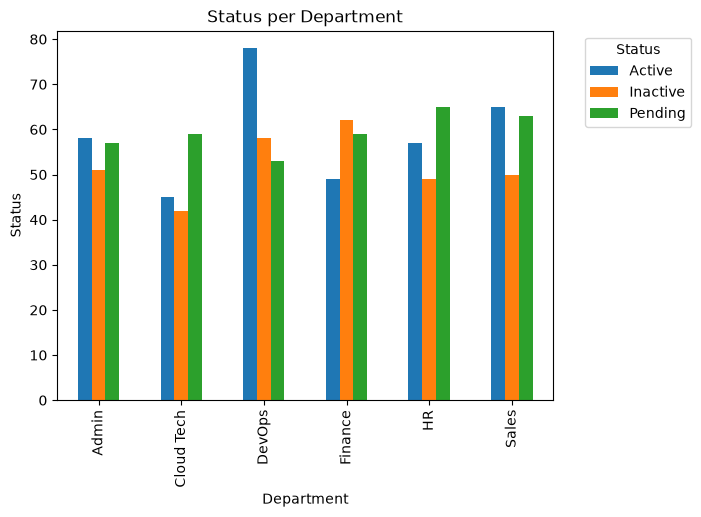

In [80]:
results.plot(kind = 'bar')
plt.xlabel('Department')
plt.ylabel('Status')
plt.title('Status per Department')

## Moving the legend outside the graph or chart
plt.legend(title = 'Status', bbox_to_anchor = (1.05, 1), loc = 'upper left')
plt.show()

## **Insight 1**

### This graph shows the number of every active, inactive and pending status of every department in the employee dataset. From this graph we can get insight and pass information

### In this bar chart we can see that the DevOps department has the highest number of active people so it is expected that the company gets more output and results from the DevOps department.

### In the bar chart we can also see that the Finance department has Inactive employees than active employees and the HR department has the most pending emloyees than active ones  so we shoud not be expecting a large amount of output or desired results from the Finance and HR department.

## Insight 2

### I want to find the highest and lowest earning  department

In [81]:
df.head()

,Employee_ID,First_Name,Last_Name,Age,Department,Region,Status,Join_Date,Salary,Email,Phone,Performance_Score,Remote_Work
0,EMP1000,Bob,Davis,25.0,DevOps,California,Active,04/02/2021,59767.65,bob.davis@example.com,-1651623197,Average,True
1,EMP1001,Bob,Brown,30.0,Finance,Texas,Active,07/10/2020,65304.66,bob.brown@example.com,-1898471390,Excellent,True
2,EMP1002,Alice,Jones,30.0,Admin,Nevada,Pending,12/07/2023,88145.90,alice.jones@example.com,-5596363211,Good,True
3,EMP1003,Eva,Davis,25.0,Admin,Nevada,Inactive,02/09/2022,69450.99,eva.davis@example.com,-3476490784,Good,True
4,EMP1004,Frank,Williams,25.0,Cloud Tech,Florida,Active,01/05/2022,109324.61,frank.williams@example.com,-1586734256,Poor,False


In [89]:
result = df.groupby('Department')['Salary'].mean()

## Sorting the values from highest to lowest
result = result.sort_values(ascending = True)

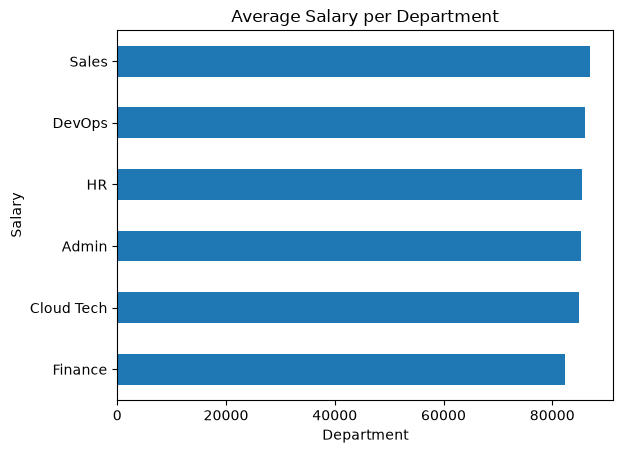

In [90]:
result.plot(kind = 'barh')
plt.xlabel('Department')
plt.ylabel('Salary')
plt.title('Average Salary per Department')
plt.show()

### In this chart the sales department are the highest earners and the finance department are the lowest earners

## **Insight 3**

### I want to find the department that are doing well in the company

In [92]:
df.head()

,Employee_ID,First_Name,Last_Name,Age,Department,Region,Status,Join_Date,Salary,Email,Phone,Performance_Score,Remote_Work
0,EMP1000,Bob,Davis,25.0,DevOps,California,Active,04/02/2021,59767.65,bob.davis@example.com,-1651623197,Average,True
1,EMP1001,Bob,Brown,30.0,Finance,Texas,Active,07/10/2020,65304.66,bob.brown@example.com,-1898471390,Excellent,True
2,EMP1002,Alice,Jones,30.0,Admin,Nevada,Pending,12/07/2023,88145.90,alice.jones@example.com,-5596363211,Good,True
3,EMP1003,Eva,Davis,25.0,Admin,Nevada,Inactive,02/09/2022,69450.99,eva.davis@example.com,-3476490784,Good,True
4,EMP1004,Frank,Williams,25.0,Cloud Tech,Florida,Active,01/05/2022,109324.61,frank.williams@example.com,-1586734256,Poor,False


In [100]:
result = df.groupby(['Department', 'Performance_Score'])['Performance_Score'].count()
results = result.unstack()
results

Performance_Score,Average,Excellent,Good,Poor
Department,,,,
Admin,40,44,49,33
Cloud Tech,40,30,49,27
DevOps,49,47,50,43
Finance,48,45,35,42
HR,41,51,39,40
Sales,49,50,48,31


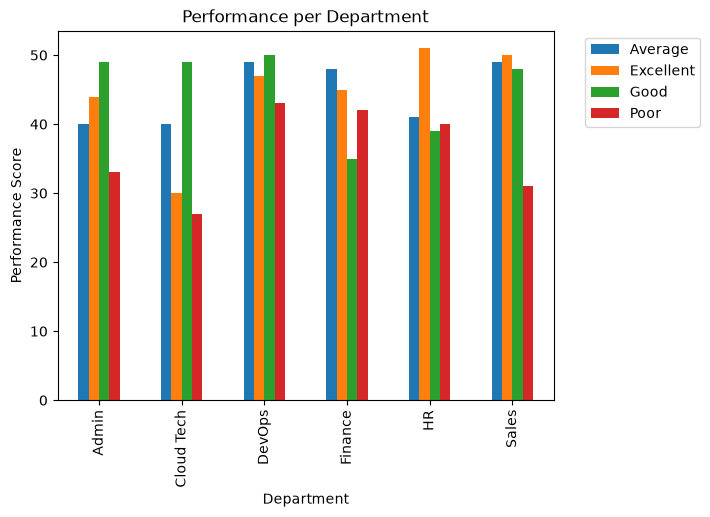

In [102]:
results.plot(kind = 'bar')
plt.xlabel('Department')
plt.ylabel('Performance Score')
plt.title('Performance per Department')
plt.legend(bbox_to_anchor = (1.05, 1), loc = 'upper left')

plt.show()

### We have fewer people doing poorly in the admin and cloud tech department 

## Insight 4 

### We want to find the highest and lowest average age per department

In [104]:
result = df.groupby('Department')['Age'].mean()
result

Department
Admin         31.746988
Cloud Tech    31.678082
DevOps        31.931217
Finance       32.588235
HR            31.871345
Sales         31.966292
Name: Age, dtype: float64

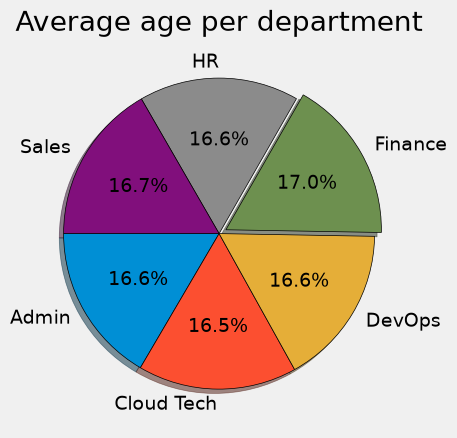

In [115]:
explode = [0, 0 , 0, 0.05, 0, 0]
plt.style.use('fivethirtyeight')
result.plot(kind = 'pie', wedgeprops = {'edgecolor' : 'black'},
            shadow = True,
           autopct = '%1.1f%%',
           startangle = 180,
           explode = explode)
plt.title('Average age per department')
plt.show()

### In this pie chart it shows the department with the highest average age. That is the department has the most people with the average age

In [116]:
df['Age'].mean()

np.float64(31.970588235294116)